Plot LPP amplitude by study position, factored by categorical features (e.g., emotion tags).


In [1]:
import os

from jaxcmr.analyses.cat_lpp_spc import plot_cat_lpp_spc
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
import matplotlib.pyplot as plt
def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
data_path = "data/TalmiEEG.h5"
trial_query =  "data['subject'] > 0"
category_field = "condition"
category_values = [1, 2]
lpp_field = "EarlyLPP"
labels = ["Negative", "Neutral"]
color_cycle = ["red", "black"]
ylim = None
figure_dir = "results/figures"
figure_str = "cat_splpp_early"


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)


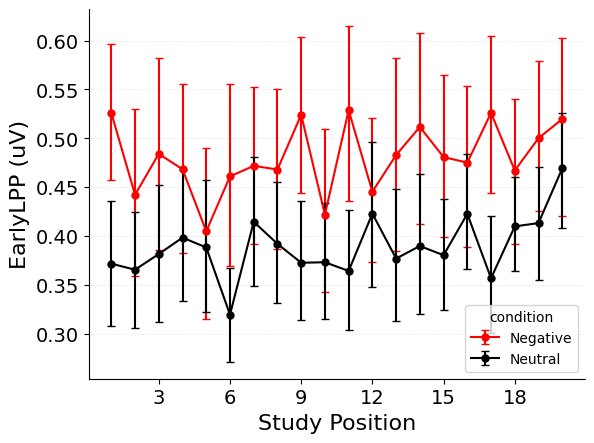

In [5]:
axis = plot_cat_lpp_spc(
    datasets=[data],
    trial_masks=trial_mask,
    category_field=category_field,
    category_values=category_values,
    lpp_field=lpp_field,
    contrast_name=category_field,
    labels=labels,
    color_cycle=color_cycle
)
axis.set_ylim(ylim)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)
